## Primero importaré pandas y exportaré la base de datos

In [1]:
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv')

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Procedemos a realizar el EDA

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Mi variable objetivo será OUTCOME, ya que es la que nos indica si una persona TIENE o NO TIENE diabetes, esta base contiene variables médicas relacionadas con pacientes, como glucosa, presión arterial, índice de masa corporal (BMI) y edad, utilizadas para predecir la presencia de diabetes.  Sin embargo, en dichas columnas existen algunos datos en ceros donde no son fisiológicamente posibles, lo que indica la presencia de datos faltantes.

In [3]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

## Aquí podemos ver que 'Insulin' tiene 374 valores en 0, luego 'SkinThickness' con 227, 'BloodPressure' 35, 'BMI' 11 y finalmente 'Glucose' 5.  

In [4]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    df[col] = df[col].replace(0, df[col].median())

## Estos valores fueron reemplazados por la mediana de cada variable, para preservar la distribución de los datos y evitar el impacto de valores extremos. Así que confirmaremos si se borraron esos datos faltantes

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Procedemos a hacer un análisis de correlación

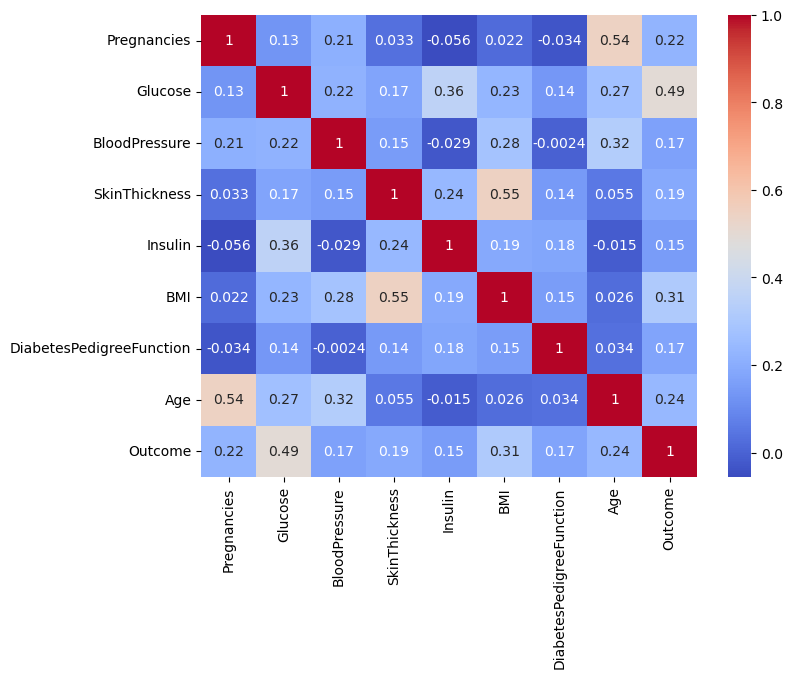

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Este mapa de calor nos arroja que la Glucosa es la correlación más importante con 49% resopecto a la variable objetivo, por lo que será nuestro indicador principal, seguido del índice de masa corporal co n 31%, la edad con 24% y el embarazo con 22%

In [7]:
df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Insulin                     0.148457
Name: Outcome, dtype: float64

## Para confirmarlo se ordenaron las variables según su correlación con la variable objetivo para identificar los predictores más relevantes. Por lo que ahora procedemos a visualizar las relaciones clave

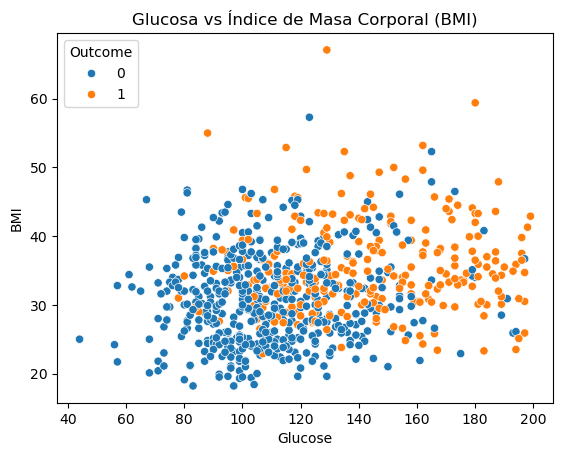

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['Glucose'], y=df['BMI'], hue=df['Outcome'])
plt.title("Glucosa vs Índice de Masa Corporal (BMI)")
plt.show()

## Este gráfico de las 2 variables más correlacionadas con la variable objetivo, OUTCOME, se observa que valores altos de glucosa y IMC están asociados con mayor probabilidad de diabetes.

## Ahora procedemos a separar el dataset en variables independientes (X = Características médicas del paciente) y confirmando que mi variable objetivo es OUTCOME (Y = tiene diabetes o no)


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome',axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Iniciaremos nuestro modelo que será de clasificación

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Ahora comenzaremos a predecir

In [11]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)


0.7532467532467533

## Mi predicción arroja un 75.32% de efectividad. Ahora explicaremos este modelo

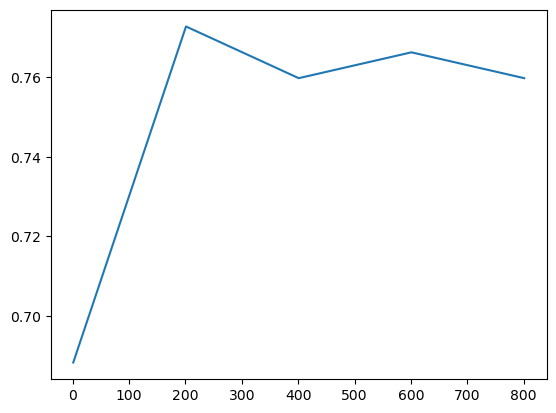

In [12]:
resultados =[]

for i in range(1,1000,200):
    cantidad_clientes = i*10
    model = RandomForestClassifier(n_estimators=i, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultados.append(accuracy_score(y_test, y_pred))

import matplotlib.pyplot as plt
plt.plot(range(1,1000,200),resultados)
plt.show()


## CONCLUSIÓN:

## Nuestro modelo al incrementar la cantidad de árboles de decisión la precisión sube en 200 a casi 78%; en 400 baja a casi un 76%; en 600 incrementa a un poco más del 76% y en 800, se mantiene cerca del 76% de precisión. Por lo que la mejor opción sería manejarlo en 200 arboles de decisión para que su accuracy esté en su punto más alto.

## Finalmente procedo a guardar mi modelo.

In [13]:
from pickle import dump

dump(model, open("../models/random_forest.sav", "wb"))